In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

In [ ]:
#Loading the Dataset

customer = pd.read_csv('/content/Mall_Customers - Mall_Customers.csv')

In [ ]:
#Selecting Relevant Columns for Clustering

points = customer.iloc[:, 3:5].values
x = points[:, 0]
y = points[:, 1]

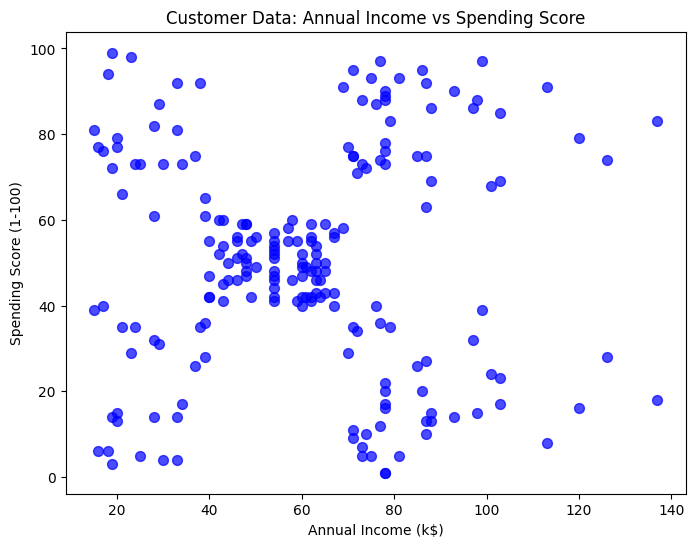

In [ ]:
#Visualizing the Raw Data

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=50, alpha=0.7, c='blue')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Data: Annual Income vs Spending Score')
plt.show()

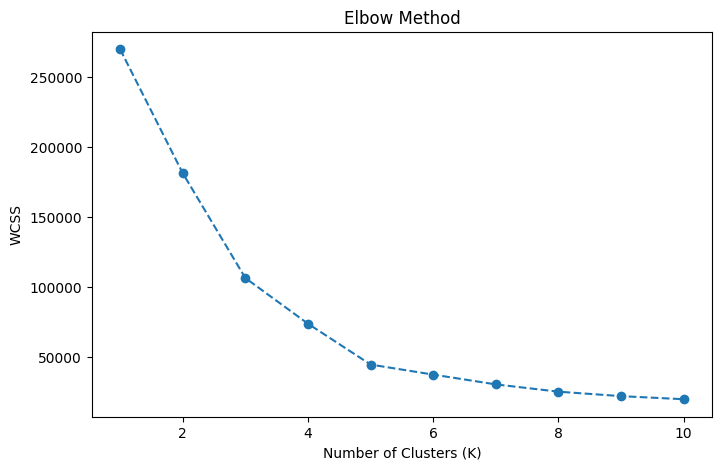

WCSS Values:
[269981.28000000014, 181363.59595959607, 106348.37306211119, 73679.78903948837, 44448.45544793369, 37265.86520484345, 30259.657207285458, 25050.832307547524, 21862.09267218289, 19657.783608703947]


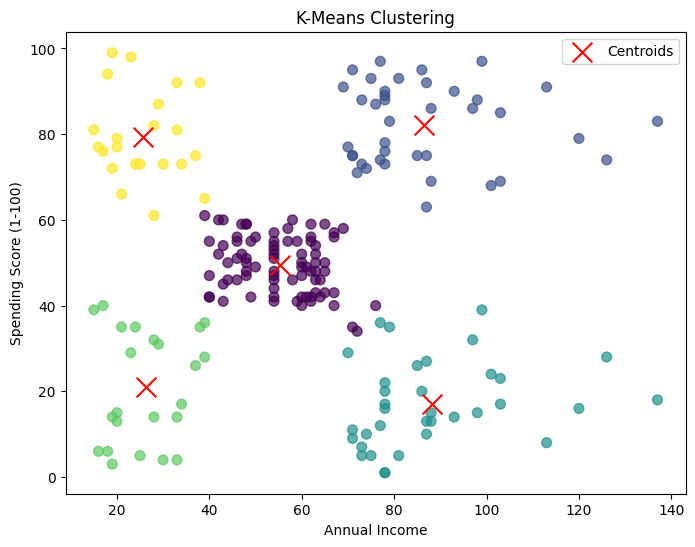

Cluster Labels:
[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]

Cluster Centers:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [88.2        17.11428571]
 [26.30434783 20.91304348]
 [25.72727273 79.36363636]]
Cluster 0 : 81 customers
Cluster 1 : 39 customers
Cluster 2 : 35 customers
Cluster 3 : 23 customers
Cluster 4 : 22 customers


In [ ]:
#Elbow Method is used to find the optimal number of clusters (K) in K-Means clustering.

#intialize empty list
wcss = []

#loop through different values of K
for i in range(1,11):
  kmeans=KMeans(
      n_clusters=i,
      init='k-means++',
      random_state=0,
      n_init=10,
     )
  kmeans.fit(points)
  #store WCSS value
  wcss.append(kmeans.inertia_)

#plot the results
plt.figure(figsize=(8, 5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

#Display WCSS values
print("WCSS Values:")
print(wcss)

#select optimal number of clusters
k=5

#create K-Means model
# Create K-Means model
kmeans = KMeans(
    n_clusters=k,
    init='k-means++',
    random_state=0,
    n_init=10
)

# Train the model
kmeans.fit(points)

# Predict cluster labels
cluster_labels = kmeans.predict(points)

# Get cluster centers
cluster_centers = kmeans.cluster_centers_

# Plot K-Means clustering
plt.figure(figsize=(8, 6))

# Plot customer clusters
plt.scatter(
    x,
    y,
    c=cluster_labels,
    s=50,
    alpha=0.7,
    cmap='viridis'
)

# Plot centroids
plt.scatter(
    cluster_centers[:, 0],
    cluster_centers[:, 1],
    s=200,
    c='red',
    marker='x',
    label='Centroids'
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score (1-100)')

plt.title('K-Means Clustering')

plt.legend()
plt.show()

print("Cluster Labels:")
print(cluster_labels)

print("\nCluster Centers:")
print(cluster_centers)

unique, counts = np.unique(
    cluster_labels,
    return_counts=True
)

for cluster, count in zip(unique, counts):
    print("Cluster", cluster, ":", count, "customers")